In [ ]:
import numpy as np
import serial
import time
import matplotlib.pyplot as plt
from IPython import display
import concurrent.futures
import serial.tools.list_ports
ports = serial.tools.list_ports.comports()
ambit_ports = [x[0] for x in ports if "CH9102" in x[1]]
print("Available ports:", ambit_ports)


Available ports: ['COM33', 'COM34']


In [5]:
def ser_readline(ser: serial.Serial, timeout = .5, get_all_lines = False):
    t0 = time.perf_counter()
    _str = ''
    bad_counter = 0
    lines = []
    while time.perf_counter() - t0 < timeout:
        if ser.in_waiting == 0:
            time.sleep(.1)
            continue
        c = ser.read()
        if (c == bytes([0])) or (c > bytes([127])):
            bad_counter += 1
            continue

        _str += c.decode()
        if (c == b"\n") or (c == b"\r"):
            _line = _str
            _str = ''
            if get_all_lines:
                t0 = time.perf_counter()
                lines.append(_line)
            else:
                return [_line]
        if bad_counter > 50:
            print("hex")
            break
    return lines


def parse_data(ret1:str)->np.ndarray:
    data = [[], [], [], [], [], []]
    for _l in ret1:
        if not _l.startswith("T:"): continue
        _s = _l.split(',')
        if len(_s) != 6: continue
        for n in range(6):
            _s2 = _s[n].split(':')
            if len(_s2) != 2: continue
            if _s2[0] == ["T", "F", "S", "R", "Sun", "L"][n]: data[n].append(float(_s2[1]))
    return np.array(data)

#helper functions
# convert protocol to ambit array
def gen_cmd_arr_line(num:int, freq:int, actinic:int)->list:
    return [2, 0, num//256, num%256, freq//256, freq%256, actinic, 1]


# flatten ambit array, calc time, actinic array
def calc_arr_param(cmd: list, persist:bool = False):
    cmd_arr = np.reshape(cmd, (-1, 8))
    arr_length = cmd_arr.shape[0]
    cmd_str = "arrun1," + str(arr_length) + "," + str(persist) + ","+ str(cmd)[1:-1] + ",\n"
    cmd_str = cmd_str.replace(" ", "")

    num_pts = cmd_arr[:, 2] * 256 + cmd_arr[:, 3]
    act_arr = cmd_arr[:, 6]
    mea_feq = 1 / (cmd_arr[:, 4] * 256 + cmd_arr[:, 5])
    _t, mea_tml, mea_act = 0, [], []
    for _n, _f, _a in zip(num_pts, mea_feq, act_arr):
        mea_tml += (np.arange(_n) * _f + _t).tolist()
        mea_act += [_a] * _n
        _t = mea_tml[-1]
    mea_tml = np.array(mea_tml) * 0.854
    return cmd_str, mea_tml, mea_act

def run2cmd(cmd1:str, cmd2:str, ser1: serial.Serial, ser2: serial.Serial, timeout = .5, get_all_lines = False)-> tuple[str, str]:    
    with concurrent.futures.ThreadPoolExecutor(max_workers=2) as executor:
        ser1.write((cmd1+'\n\r').encode())
        ser2.write((cmd2+'\n\r').encode())
        f1 = executor.submit(ser_readline, ser1, timeout, get_all_lines)
        f2 = executor.submit(ser_readline, ser2, timeout, get_all_lines)
        result1 = f1.result()
        result2 = f2.result()
        return result1, result2

In [50]:
with serial.Serial(ambit_ports[0], baudrate=115200) as ser1:
    with serial.Serial(ambit_ports[1], baudrate=115200) as ser2:
        r1, r2 = run2cmd("hello", "hello", ser1, ser2, 1, True)
        print("Ambit 1:", r1)
        print("Ambit 2:", r2)


Ambit 1: ['NEW Name Here Ready\r', '\n']
Ambit 2: ['NEW Name Here Ready\r', '\n']


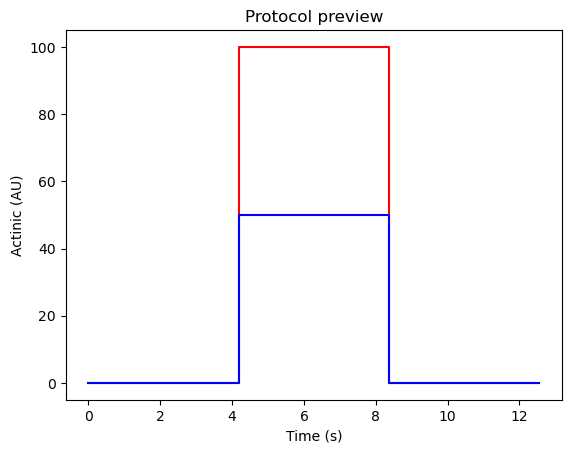

In [8]:
light_intensity_test_protocols1 = []
light_intensity_test_protocols2 = []
# create a trace with 3 different setups:
# 1. 50 points, 10Hz, no actinic
# 2. 50 points, 50Hz, 240/255(max) actinic
# 3. 50 points, 10Hz, no actinic
# number of lines (1 - 8) points(10 - 2000), freq (1 - 200), actinic 0 - 255

cmd1 = []
cmd1 += gen_cmd_arr_line(num = 50, freq = 10, actinic = 0)
cmd1 += gen_cmd_arr_line(num = 50, freq = 10, actinic = 100)
cmd1 += gen_cmd_arr_line(num = 50, freq = 10, actinic = 0)
wait_time1 = 1

cmd2 = []
cmd2 += gen_cmd_arr_line(num = 50, freq = 10, actinic = 0)
cmd2 += gen_cmd_arr_line(num = 50, freq = 10, actinic = 50)
cmd2 += gen_cmd_arr_line(num = 50, freq = 10, actinic = 0)
wait_time2 = 1


# convert to command for ambit, also pre-calculate the time and actinic of each point
cmd_str1, timeline1, act_arr1 = calc_arr_param(cmd1, 0)
cmd_str2, timeline2, act_arr2 = calc_arr_param(cmd2, 0)
plt.plot(timeline1, act_arr1, 'r')
plt.plot(timeline2, act_arr2, 'b')
plt.xlabel("Time (s)")
plt.ylabel("Actinic (AU)")
plt.title("Protocol preview")


light_intensity_test_protocols1.append((cmd_str1, timeline1, act_arr1, wait_time1))
light_intensity_test_protocols2.append((cmd_str2, timeline2, act_arr2, wait_time2))

In [14]:
with serial.Serial(ambit_ports[0], baudrate=115200) as ser1:
    with serial.Serial(ambit_ports[1], baudrate=115200) as ser2:
        for (cmd_str1, timeline1, act_arr1, wt1), (cmd_str2, timeline2, act_arr2, wt2) in zip(light_intensity_test_protocols1, light_intensity_test_protocols2):
            ret1, ret2 = run2cmd(cmd_str1, cmd_str2, ser1, ser2, max(wt1,wt2), True)


In [66]:
protocols1,  protocols2 = [], []

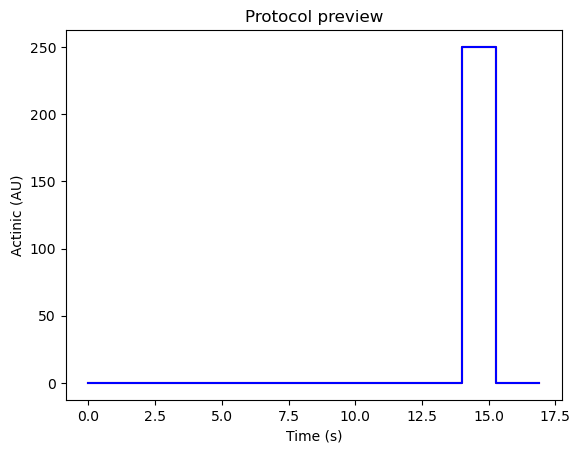

In [69]:
# create a trace with 3 different setups:
# 1. 50 points, 10Hz, no actinic
# 2. 50 points, 50Hz, 240/255(max) actinic
# 3. 50 points, 10Hz, no actinic
# number of lines (1 - 8) points(10 - 2000), freq (1 - 200), actinic 0 - 255

_cmd1, _cmd2 = [], []

_cmd1 += gen_cmd_arr_line(num = 30, freq = 2, actinic = 0)
_cmd2 += gen_cmd_arr_line(num = 30, freq = 2, actinic = 0)

_cmd1 += gen_cmd_arr_line(num = 20, freq = 10, actinic = 0)
_cmd2 += gen_cmd_arr_line(num = 20, freq = 10, actinic = 0)

_cmd1 += gen_cmd_arr_line(num = 150, freq = 100, actinic = 250)
_cmd2 += gen_cmd_arr_line(num = 150, freq = 100, actinic = 250)

_cmd1 += gen_cmd_arr_line(num = 20, freq = 10, actinic = 0)
_cmd2 += gen_cmd_arr_line(num = 20, freq = 10, actinic = 0)

wait_time1 = 5
wait_time2 = 2

# convert to command for ambit, also pre-calculate the time and actinic of each point
cmd_str1, timeline1, act_arr1 = calc_arr_param(_cmd1, 0)
cmd_str2, timeline2, act_arr2 = calc_arr_param(_cmd2, 0)
plt.plot(timeline1, act_arr1, 'r')
plt.plot(timeline2, act_arr2, 'b')
plt.xlabel("Time (s)")
plt.ylabel("Actinic (AU)")
plt.title("Protocol preview")


protocols1.append((cmd_str1, timeline1, act_arr1, wait_time1))
protocols2.append((cmd_str2, timeline2, act_arr2, wait_time2))

In [ ]:
fig, ax1 = plt.subplots(1, 1)
ax2 = ax1.twinx()
ax3 = ax1.twinx()
ax3.spines['right'].set_position(('outward', 60))  # Offset
_trace1 = ax1.plot([], [], 'r')[0]
_trace2 = ax2.plot([], [], 'b')[0]
_trace3 = ax3.plot([], [], 'g')[0]
_trace4 = ax3.plot([], [], 'y')[0]

_t0 = time.perf_counter()
data = []

for cycle in range(2):
    with serial.Serial(ambit_ports[0], baudrate=115200) as ser1:
        with serial.Serial(ambit_ports[1], baudrate=115200) as ser2:            
            for (cmd_str1, timeline1, act_arr1, wt1), (cmd_str2, timeline2, act_arr2, wt2) in zip(protocols1, protocols2):
                _ts = time.perf_counter()
                ret1, ret2 = run2cmd(cmd_str1, cmd_str2, ser1, ser2, max(wt1, wt2), True)
                data.append((_ts - _t0, [parse_data(ret1), parse_data(ret2)], [timeline1, timeline2], [act_arr1, act_arr2]))

    X1, X2, T1, T2, F1, F2 = [], [], [], [], [], []
    for t0, fluos, tl, arr in data:
        temp1, temp2 = fluos[0][0,:], fluos[1][0,:]
        f1, f2 = fluos[0][2,:]/fluos[0][3,:], fluos[1][2,:]/fluos[1][3,:]
        T1 += temp1.tolist()
        T2 += temp2.tolist()
        F1 += f1.tolist()
        F2 += f2.tolist()
        X1 += (tl[0] + t0).tolist()
        X2 += (tl[1] + t0).tolist()
    _trace1.set_data(X1, F1)
    _trace2.set_data(X2, F2)
    _trace3.set_data(X1, T1)
    _trace4.set_data(X2, T2)
    ax1.set_xlim(0, np.max([X1, X2]))
    ax1.set_ylim(.95 * min(F1), 1.05 * max(F1))
    ax2.set_ylim(.95 * min(F1), 1.05 * max(F2))
    ax3.set_ylim(min(T1 + T2)-2, 2 + max(T1 + T2))
    display.display(fig, display_id='live_plot')
    display.clear_output(wait=True)


    time.sleep(10)  # wait for the plot to update

    

np.float64(14.930905500007178)

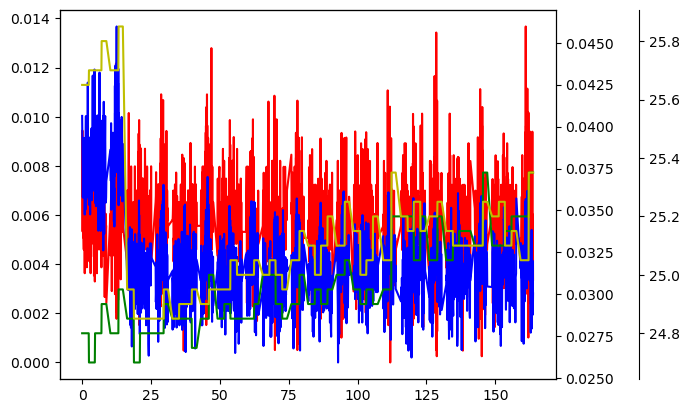

In [39]:
fig, ax1 = plt.subplots(1, 1)
ax2 = ax1.twinx()
ax3 = ax1.twinx()
ax3.spines['right'].set_position(('outward', 60))  # Offset
_trace1 = ax1.plot([], [], 'r')[0]
_trace2 = ax2.plot([], [], 'b')[0]

X1, X2, T1, T2, F1, F2 = [], [], [], [], [], []
for t0, fluos, tl, arr in data:
    temp1, temp2 = fluos[0][0,:], fluos[1][0,:]
    f1, f2 = fluos[0][2,:]/fluos[0][3,:], fluos[1][2,:]/fluos[1][3,:]
    T1 += temp1.tolist()
    T2 += temp2.tolist()
    F1 += f1.tolist()
    F2 += f2.tolist()
    X1 += (tl[0] + t0).tolist()
    X2 += (tl[1] + t0).tolist()

ax1.plot(X1, F1, 'r')
ax2.plot(X2, F2, 'b')
ax3.plot(X1, T1, 'g')
ax3.plot(X2, T2, 'y')


 

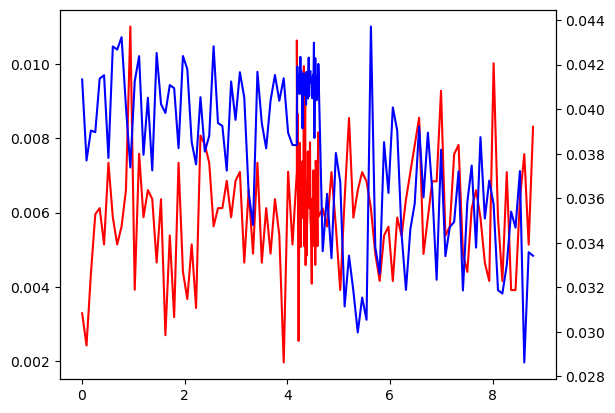

In [12]:
_, axis = plt.subplots(1, 1)
ax2 = axis.twinx()
for t0, fluos, tl, arr in data:
    f1 = fluos[0][2,:]/fluos[0][3,:]
    f2 = fluos[1][2,:]/fluos[1][3,:]
    axis.plot(tl[0] + t0, f1, 'r')
    ax2.plot(tl[1] + t0, f2, 'b')

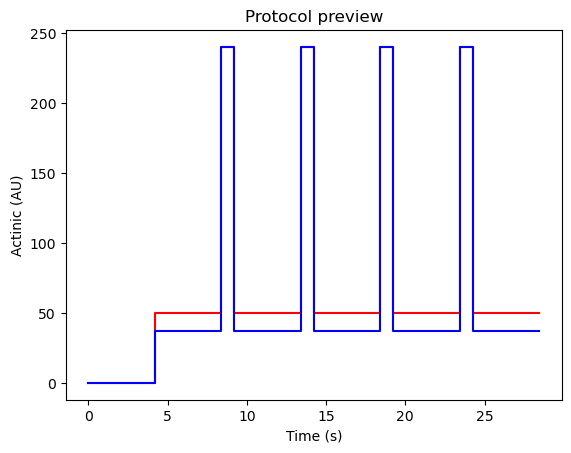

In [54]:
# create a trace with 3 different setups:
# 1. 50 points, 10Hz, no actinic
# 2. 50 points, 50Hz, 240/255(max) actinic
# 3. 50 points, 10Hz, no actinic
# number of lines (1 - 8) points(10 - 2000), freq (1 - 200), actinic 0 - 255
actinic_intensity = 50
second_actinic = int(0.75 * actinic_intensity)


_cmd1, _cmd2 = [], []
_cmd1 += gen_cmd_arr_line(num = 50, freq = 10, actinic = 0)
_cmd2 += gen_cmd_arr_line(num = 50, freq = 10, actinic = 0)

for n in range(4):
    _cmd1 += gen_cmd_arr_line(num = 50, freq = 10, actinic = actinic_intensity)
    _cmd2 += gen_cmd_arr_line(num = 50, freq = 10, actinic = second_actinic)

    _cmd1 += gen_cmd_arr_line(num = 50, freq = 50, actinic = 240)
    _cmd2 += gen_cmd_arr_line(num = 50, freq = 50, actinic = 240)

_cmd1 += gen_cmd_arr_line(num = 50, freq = 10, actinic = actinic_intensity)
_cmd2 += gen_cmd_arr_line(num = 50, freq = 10, actinic = second_actinic)

wait_time1 = 1
wait_time2 = 1

# convert to command for ambit, also pre-calculate the time and actinic of each point
cmd_str1, timeline1, act_arr1 = calc_arr_param(_cmd1, 0)
cmd_str2, timeline2, act_arr2 = calc_arr_param(_cmd2, 0)
plt.plot(timeline1, act_arr1, 'r')
plt.plot(timeline2, act_arr2, 'b')
plt.xlabel("Time (s)")
plt.ylabel("Actinic (AU)")
plt.title("Protocol preview")


protocols1.append((cmd_str1, timeline1, act_arr1, wait_time1))
protocols2.append((cmd_str2, timeline2, act_arr2, wait_time2))

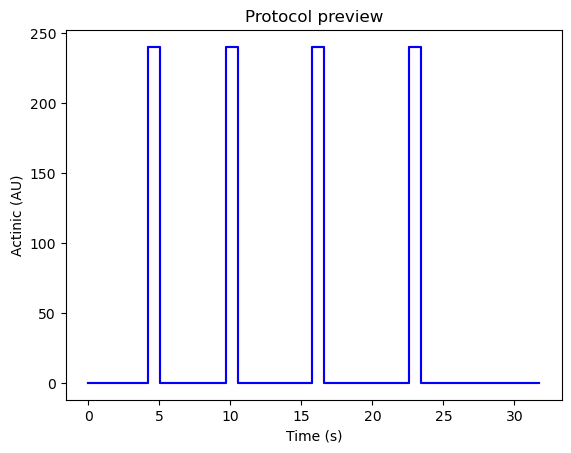

In [55]:
# create a trace with 3 different setups:
# 1. 50 points, 10Hz, no actinic
# 2. 50 points, 50Hz, 240/255(max) actinic
# 3. 50 points, 10Hz, no actinic
# number of lines (1 - 8) points(10 - 2000), freq (1 - 200), actinic 0 - 255
_cmd1, _cmd2 = [], []

for freq in [10, 9, 8, 7]:
    _cmd1 += gen_cmd_arr_line(num = 50, freq = freq, actinic = 0)
    _cmd1 += gen_cmd_arr_line(num = 50, freq = 50, actinic = 240)
_cmd1 += gen_cmd_arr_line(num = 50, freq = 5, actinic = 0)
_cmd2 = _cmd1

wait_time1 = 5
wait_time2 = 5

# convert to command for ambit, also pre-calculate the time and actinic of each point
cmd_str1, timeline1, act_arr1 = calc_arr_param(_cmd1, 0)
cmd_str2, timeline2, act_arr2 = calc_arr_param(_cmd2, 0)
plt.plot(timeline1, act_arr1, 'r')
plt.plot(timeline2, act_arr2, 'b')
plt.xlabel("Time (s)")
plt.ylabel("Actinic (AU)")
plt.title("Protocol preview")


protocols1.append((cmd_str1, timeline1, act_arr1, wait_time1))
protocols2.append((cmd_str2, timeline2, act_arr2, wait_time2))

In [56]:
_t0 = time.perf_counter()
with serial.Serial(ambit_ports[0], baudrate=115200) as ser1:
    with serial.Serial(ambit_ports[1], baudrate=115200) as ser2:
        data = []
        for (cmd_str1, timeline1, act_arr1, wt1), (cmd_str2, timeline2, act_arr2, wt2) in zip(protocols1, protocols2):
            _ts = time.perf_counter()
            ret1, ret2 = run2cmd(cmd_str1, cmd_str2, ser1, ser2, max(wt1, wt2), True)
            print(max(wt1, wt2))
            data.append((_ts - _t0, [parse_data(ret1), parse_data(ret2)], [timeline1, timeline2], [act_arr1, act_arr2]))

          


1
1
5


In [57]:
for t0, fluos, tl, arr in data:
    print(fluos[0].shape, fluos[1].shape)
    print(tl[0].shape, tl[1].shape)

(6, 150) (6, 150)
(150,) (150,)
(6, 500) (6, 500)
(500,) (500,)
(6, 450) (6, 450)
(450,) (450,)


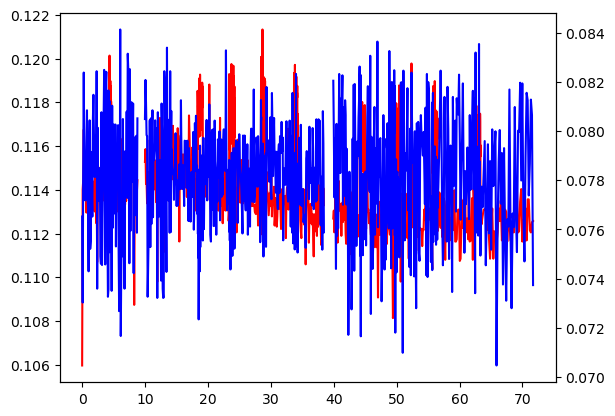

In [58]:
# norm1 = lambda x:  (x - x[10:40].mean()) / (x[60:90].mean() - x[10:40].mean())

_, axis = plt.subplots(1, 1)
ax2 = axis.twinx()
for t0, fluos, tl, arr in data:
    f1 = fluos[0][2,:]/fluos[0][3,:]
    f2 = fluos[1][2,:]/fluos[1][3,:]
    axis.plot(tl[0] + t0, f1, 'r')
    ax2.plot(tl[1] + t0, f2, 'b')